# Notebook 03 — Modelos y Evaluación

**Objetivo:** entrenar y comparar los tres algoritmos de Data Mining.

| Experimento | Algoritmo | Dataset | Propósito |
|---|---|---|---|
| 1 | Isolation Forest | logs propios | Detección base |
| 2 | K-Means | logs propios | Comparación |
| 3 | DBSCAN | logs propios | Comparación |
| 4 | Comparación final | logs propios | Tabla de métricas |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score
)
from sklearn.decomposition import PCA

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

DATA    = Path('../datasets/processed/features.csv')
FIG_DIR = Path('../docs/figures')
MDL_DIR = Path('../models')
FIG_DIR.mkdir(parents=True, exist_ok=True)
MDL_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
df = pd.read_csv(DATA)

if 'label' in df.columns:
    y_true_raw = df['label'].copy()
    X = df.drop(columns=['label'])
    # 1 = anomalía, 0 = normal
    y_true = (y_true_raw != 'normal').astype(int)
    print(f'X: {X.shape}  |  anomalías: {y_true.sum()} ({y_true.mean():.1%})')
else:
    X = df.copy()
    y_true = None
    y_true_raw = None
    print(f'X: {X.shape} (sin label, modo no supervisado puro)')

X: (22844, 18)  |  anomalías: 6145 (26.9%)


## Experimento 1 — Isolation Forest

Algoritmo principal de la tesis. Detecta anomalías aislando puntos mediante particiones aleatorias. Los puntos que se aíslan con pocas particiones son anómalos.

In [3]:
# Contamination fija: en producción no conocemos el ratio real de anomalías.
# Valor conservador recomendado en la literatura: 0.05-0.10
contamination = 0.05

print(f'Contamination configurada: {contamination:.3f}')

iso = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)
iso.fit(X)

# -1 = anomalía, 1 = normal  (convención de sklearn)
if_pred_raw = iso.predict(X)
if_scores   = iso.decision_function(X)  # score continuo: más bajo = más anómalo
if_pred     = (if_pred_raw == -1).astype(int)  # 1 = anomalía

print(f'Anomalías detectadas: {if_pred.sum():,} ({if_pred.mean():.1%})')
joblib.dump(iso, MDL_DIR / 'isolation_forest.pkl')
print('Modelo guardado: models/isolation_forest.pkl')

Contamination configurada: 0.050


Anomalías detectadas: 1,143 (5.0%)
Modelo guardado: models/isolation_forest.pkl


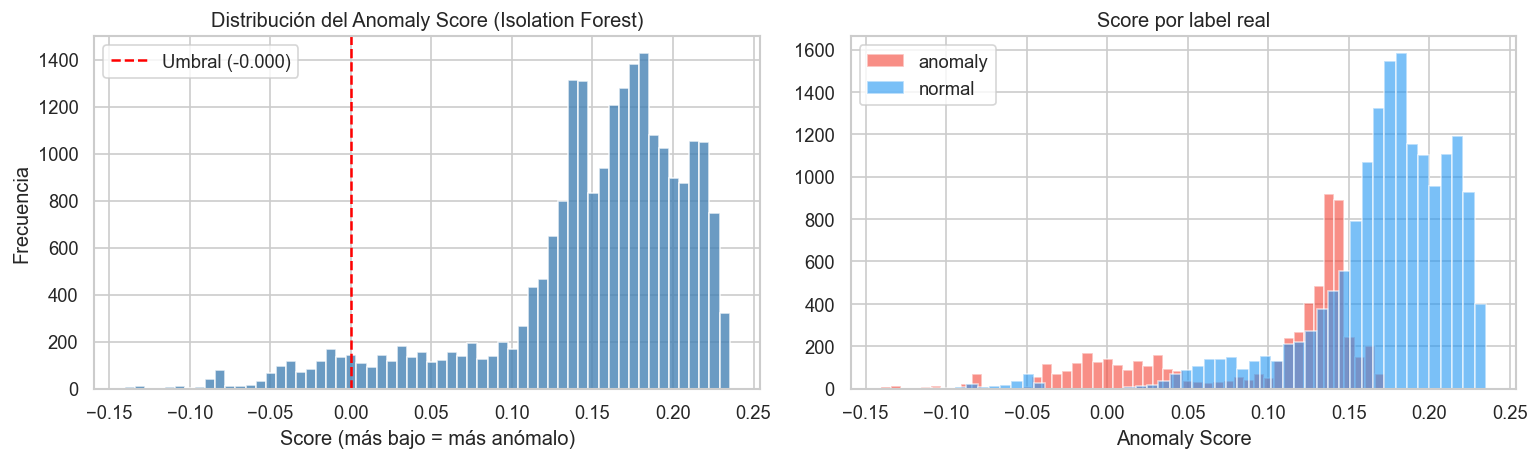

In [4]:
# Distribución del anomaly score
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma de scores
axes[0].hist(if_scores, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
threshold = np.percentile(if_scores, contamination * 100)
axes[0].axvline(threshold, color='red', linestyle='--', label=f'Umbral ({threshold:.3f})')
axes[0].set_title('Distribución del Anomaly Score (Isolation Forest)')
axes[0].set_xlabel('Score (más bajo = más anómalo)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Score por label real (si existe)
if y_true is not None:
    score_df = pd.DataFrame({'score': if_scores, 'label': y_true_raw.values})
    for lbl, grp in score_df.groupby('label'):
        color = '#F44336' if lbl != 'normal' else '#2196F3'
        axes[1].hist(grp['score'], bins=50, alpha=0.6, label=lbl, color=color)
    axes[1].set_title('Score por label real')
    axes[1].set_xlabel('Anomaly Score')
    axes[1].legend()
else:
    axes[1].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / 'if_scores.png', bbox_inches='tight')
plt.show()

=== Isolation Forest ===
              precision    recall  f1-score   support

      normal       0.76      0.99      0.86     16699
     anomaly       0.82      0.15      0.26      6145

    accuracy                           0.76     22844
   macro avg       0.79      0.57      0.56     22844
weighted avg       0.78      0.76      0.70     22844

ROC-AUC: 0.8871


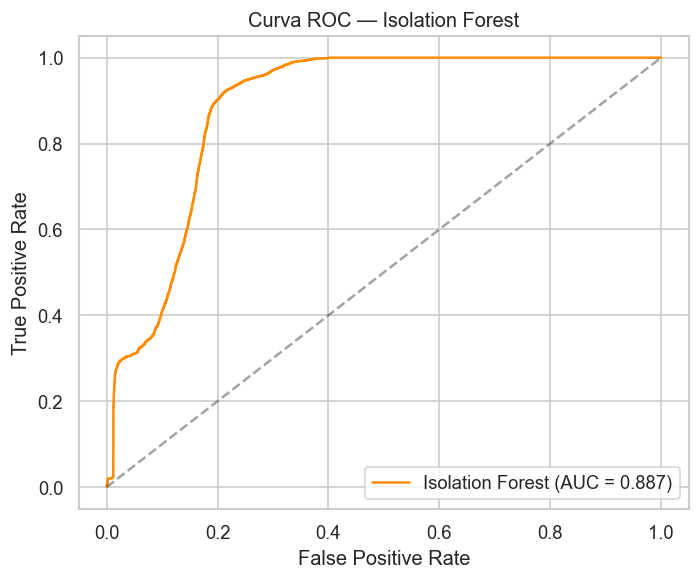

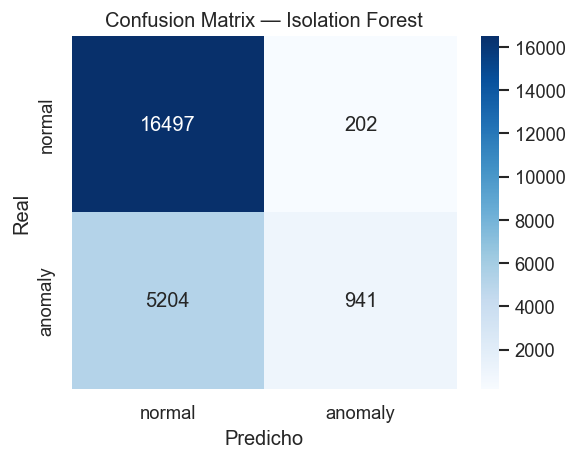

In [5]:
# Métricas Isolation Forest
if y_true is not None:
    print('=== Isolation Forest ===')
    print(classification_report(y_true, if_pred, target_names=['normal', 'anomaly']))

    # ROC-AUC usando score continuo (invertido: anomalía = score bajo)
    auc = roc_auc_score(y_true, -if_scores)
    print(f'ROC-AUC: {auc:.4f}')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_true, -if_scores)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, label=f'Isolation Forest (AUC = {auc:.3f})', color='darkorange')
    ax.plot([0,1],[0,1], 'k--', alpha=0.4)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('Curva ROC — Isolation Forest')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'roc_if.png', bbox_inches='tight')
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(y_true, if_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['normal','anomaly'], yticklabels=['normal','anomaly'])
    ax.set_title('Confusion Matrix — Isolation Forest')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'cm_isolation_forest.png', bbox_inches='tight')
    plt.show()

### Análisis de sensibilidad — impacto de `contamination`

`contamination=0.05` es una estimación conservadora a priori (no usa el label real). Para entender qué tan sensible es el modelo a esa elección, se recalculan las métricas variando `contamination` en un rango realista, incluyendo como referencia el valor con fuga de información (`0.27` = % real de anomalías, solo para contraste — no usar en producción).

,contamination,Precision,Recall,F1-Score,ROC-AUC
0,0.030000,0.7055,0.0788,0.1417,0.8871
1,0.050000,0.8233,0.1531,0.2582,0.8871
2,0.080000,0.8649,0.2573,0.3966,0.8871
3,0.100000,0.7991,0.2972,0.4332,0.8871
4,0.150000,0.6204,0.3460,0.4442,0.8871
5,0.200000,0.5986,0.4451,0.5105,0.8871
6,0.270000,0.6039,0.6062,0.6051,0.8871
7,0.300000,0.6135,0.6841,0.6469,0.8871


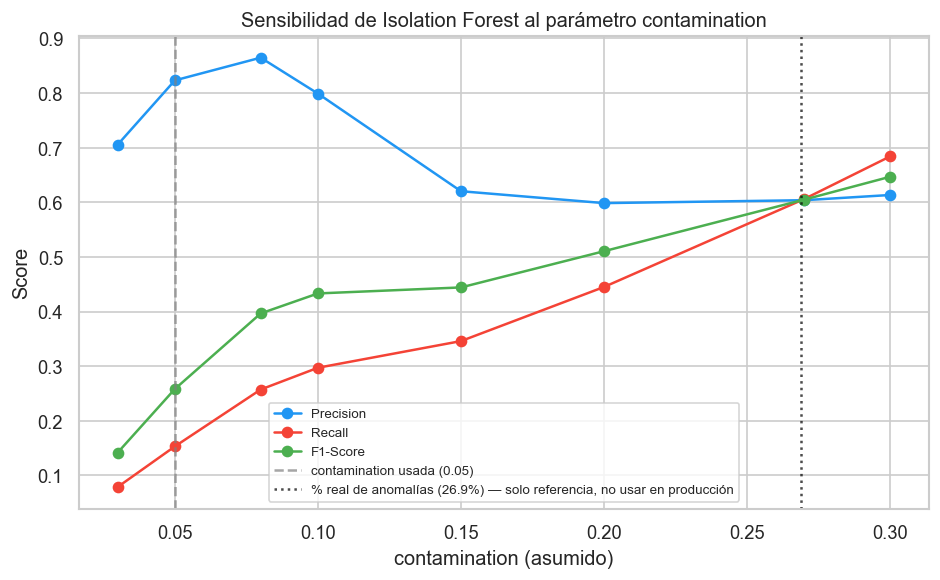


Con contamination honesto (0.05): F1=0.258
Con contamination con fuga (0.27): F1=0.605


In [6]:
contamination_range = [0.03, 0.05, 0.08, 0.10, 0.15, 0.20, 0.27, 0.30]
sens_rows = []
for c in contamination_range:
    m = IsolationForest(n_estimators=200, contamination=c, max_samples='auto',
                         random_state=42, n_jobs=-1).fit(X)
    pred = (m.predict(X) == -1).astype(int)
    scores = m.decision_function(X)
    sens_rows.append({
        'contamination': c,
        'Precision': precision_score(y_true, pred, zero_division=0),
        'Recall': recall_score(y_true, pred, zero_division=0),
        'F1-Score': f1_score(y_true, pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, -scores),
    })

sens_df = pd.DataFrame(sens_rows)
sens_df.to_csv('../datasets/processed/contamination_sensitivity.csv', index=False)
display(sens_df.style.format({c: '{:.4f}' for c in sens_df.columns if c != 'contamination'}))

real_rate = y_true.mean()
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sens_df['contamination'], sens_df['Precision'], 'o-', label='Precision', color='#2196F3')
ax.plot(sens_df['contamination'], sens_df['Recall'],    'o-', label='Recall',    color='#F44336')
ax.plot(sens_df['contamination'], sens_df['F1-Score'],  'o-', label='F1-Score',  color='#4CAF50')
ax.axvline(0.05, color='gray', linestyle='--', alpha=0.7, label='contamination usada (0.05)')
ax.axvline(real_rate, color='black', linestyle=':', alpha=0.7,
           label=f'% real de anomalías ({real_rate:.1%}) — solo referencia, no usar en producción')
ax.set_xlabel('contamination (asumido)')
ax.set_ylabel('Score')
ax.set_title('Sensibilidad de Isolation Forest al parámetro contamination')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'if_contamination_sensitivity.png', bbox_inches='tight')
plt.show()

print(f'\nCon contamination honesto (0.05): F1={sens_df.loc[sens_df.contamination==0.05, "F1-Score"].values[0]:.3f}')
print(f'Con contamination con fuga (0.27): F1={sens_df.loc[sens_df.contamination==0.27, "F1-Score"].values[0]:.3f}')

## Experimento 2 — K-Means

Agrupa los logs en k clusters. El cluster con menor cantidad de puntos se asume que contiene anomalías.

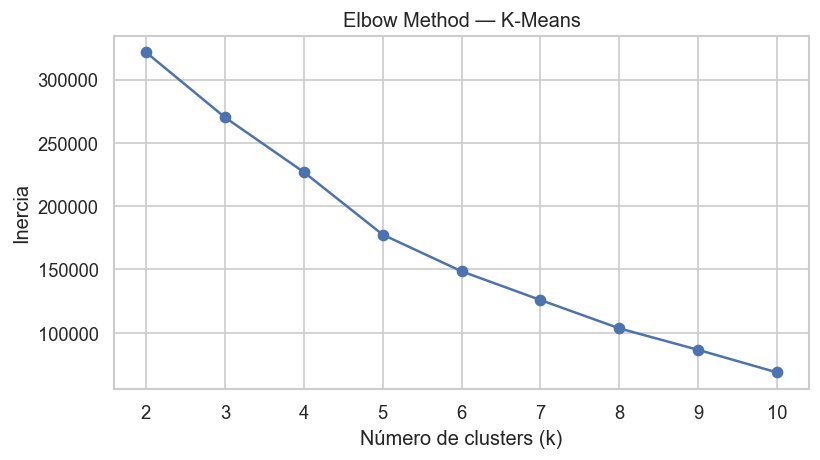

Elegí el k donde la curva deja de bajar bruscamente (codo de la curva)


In [7]:
# Elbow method para elegir k óptimo
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_range, inertias, 'bo-', markersize=6)
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Inercia')
ax.set_title('Elbow Method — K-Means')
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.savefig(FIG_DIR / 'kmeans_elbow.png', bbox_inches='tight')
plt.show()
print('Elegí el k donde la curva deja de bajar bruscamente (codo de la curva)')

In [8]:
K_OPTIMAL = 2  # elbow method no muestra un quiebre neto (caída ~16-22% en cada paso,
                # sin codo claro); se mantiene k=2 por su interpretación directa
                # (normal / anómalo) y porque k=3 produjo un cluster degenerado de 1 punto.

km = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=20)
km_labels = km.fit_predict(X)

# El cluster más pequeño se considera anómalo
cluster_sizes = pd.Series(km_labels).value_counts()
print('Tamaño de clusters:')
print(cluster_sizes)

anomaly_cluster = cluster_sizes.idxmin()
print(f'\nCluster anómalo (más pequeño): {anomaly_cluster}')

km_pred = (km_labels == anomaly_cluster).astype(int)
print(f'Anomalías detectadas: {km_pred.sum():,} ({km_pred.mean():.1%})')

joblib.dump(km, MDL_DIR / 'kmeans.pkl')

Tamaño de clusters:
1    17246
0     5598
Name: count, dtype: int64

Cluster anómalo (más pequeño): 0
Anomalías detectadas: 5,598 (24.5%)


['../models/kmeans.pkl']

/Users/ever/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


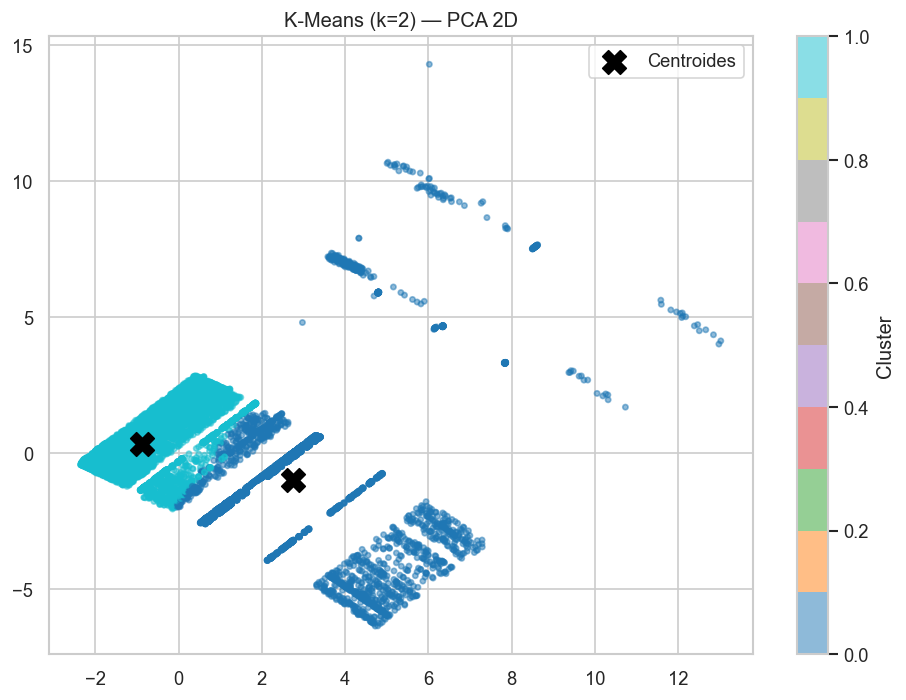

In [9]:
# Visualizar clusters en PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels,
                     cmap='tab10', alpha=0.5, s=10)
centers_pca = pca.transform(km.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
           c='black', marker='X', s=200, zorder=5, label='Centroides')
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_title(f'K-Means (k={K_OPTIMAL}) — PCA 2D')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'kmeans_clusters.png', bbox_inches='tight')
plt.show()

In [10]:
if y_true is not None:
    print('=== K-Means ===')
    print(classification_report(y_true, km_pred, target_names=['normal', 'anomaly']))

=== K-Means ===
              precision    recall  f1-score   support

      normal       0.94      0.97      0.95     16699
     anomaly       0.90      0.82      0.86      6145

    accuracy                           0.93     22844
   macro avg       0.92      0.89      0.91     22844
weighted avg       0.93      0.93      0.93     22844



## Experimento 3 — DBSCAN

Detecta regiones densas de puntos. Los puntos que no pertenecen a ningún cluster (label = -1) son considerados anomalías (ruido).

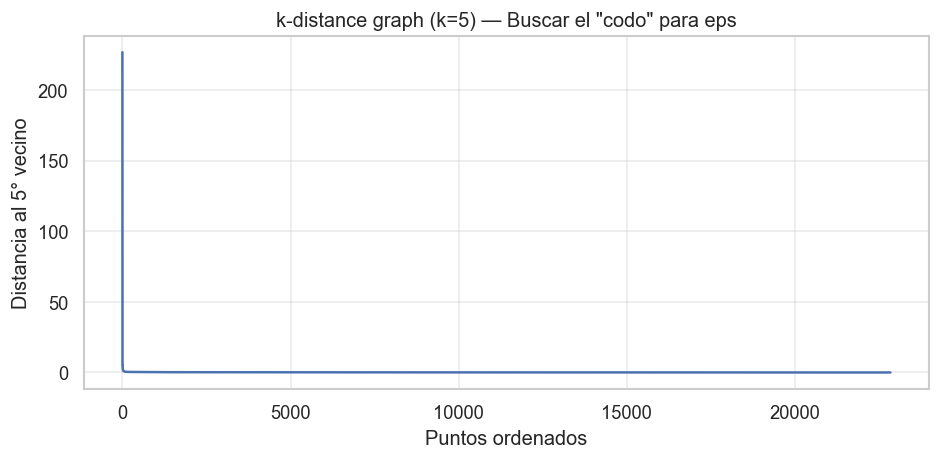

Elegí el eps en el codo de esta curva


In [11]:
# Buscar eps óptimo con k-distance graph
from sklearn.neighbors import NearestNeighbors

k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X)
distances, _ = nbrs.kneighbors(X)
k_distances = np.sort(distances[:, k-1])[::-1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_distances)
ax.set_title(f'k-distance graph (k={k}) — Buscar el "codo" para eps')
ax.set_xlabel('Puntos ordenados')
ax.set_ylabel(f'Distancia al {k}° vecino')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / 'dbscan_kdistance.png', bbox_inches='tight')
plt.show()
print('Elegí el eps en el codo de esta curva')

In [12]:
EPS = 0.3       # k-distance graph: el "codo" cae ~percentil 1-2 (dist. 0.32-0.38);
                # eps=0.3 deja como ruido a la porción minoritaria más alejada,
                # consistente con esperar que las anomalías sean minoría.
MIN_SAMPLES = 5 # mínimo de puntos para formar un cluster

db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1)
db_labels = db.fit_predict(X)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = (db_labels == -1).sum()

print(f'Clusters encontrados: {n_clusters}')
print(f'Puntos de ruido (anomalías): {n_noise:,} ({n_noise/len(X):.1%})')

db_pred = (db_labels == -1).astype(int)

joblib.dump(db, MDL_DIR / 'dbscan.pkl')

Clusters encontrados: 91


Puntos de ruido (anomalías): 270 (1.2%)


['../models/dbscan.pkl']

In [13]:
if y_true is not None:
    print('=== DBSCAN ===')
    print(classification_report(y_true, db_pred, target_names=['normal', 'anomaly']))

=== DBSCAN ===
              precision    recall  f1-score   support

      normal       0.74      0.99      0.85     16699
     anomaly       0.61      0.03      0.05      6145

    accuracy                           0.73     22844
   macro avg       0.67      0.51      0.45     22844
weighted avg       0.70      0.73      0.63     22844



## Experimento 4 — Comparación final de algoritmos

Tabla de métricas para el capítulo de resultados de la tesis.

In [14]:
if y_true is not None:
    def metrics(name, y_t, y_p, scores=None):
        row = {
            'Algoritmo':   name,
            'Precision':   precision_score(y_t, y_p, zero_division=0),
            'Recall':      recall_score(y_t, y_p, zero_division=0),
            'F1-Score':    f1_score(y_t, y_p, zero_division=0),
            'Anomalías detectadas': int(y_p.sum()),
        }
        if scores is not None:
            try:
                row['ROC-AUC'] = roc_auc_score(y_t, scores)
            except Exception:
                row['ROC-AUC'] = None
        return row

    results = pd.DataFrame([
        metrics('Isolation Forest', y_true, if_pred, scores=-if_scores),
        metrics('K-Means',          y_true, km_pred),
        metrics('DBSCAN',           y_true, db_pred),
    ])
    results = results.set_index('Algoritmo')

    numeric_cols_r = results.select_dtypes(include='number').columns
    styled = results.style.format({c: '{:.4f}' for c in numeric_cols_r})\
                          .highlight_max(subset=numeric_cols_r, color='lightgreen')\
                          .highlight_min(subset=['ROC-AUC','F1-Score','Recall'], color='lightsalmon')
    display(styled)

    results.to_csv('../datasets/processed/model_comparison.csv')
    print('\nGuardado: datasets/processed/model_comparison.csv')

else:
    print('Sin label real: no se pueden calcular métricas supervisadas.')
    print('Anomalías detectadas:')
    print(f'  Isolation Forest: {if_pred.sum():,}')
    print(f'  K-Means:          {km_pred.sum():,}')
    print(f'  DBSCAN:           {db_pred.sum():,}')

,Precision,Recall,F1-Score,Anomalías detectadas,ROC-AUC
Algoritmo,,,,,
Isolation Forest,0.8233,0.1531,0.2582,1143.0000,0.8871
K-Means,0.9025,0.8221,0.8604,5598.0000,nan
DBSCAN,0.6111,0.0269,0.0514,270.0000,nan



Guardado: datasets/processed/model_comparison.csv


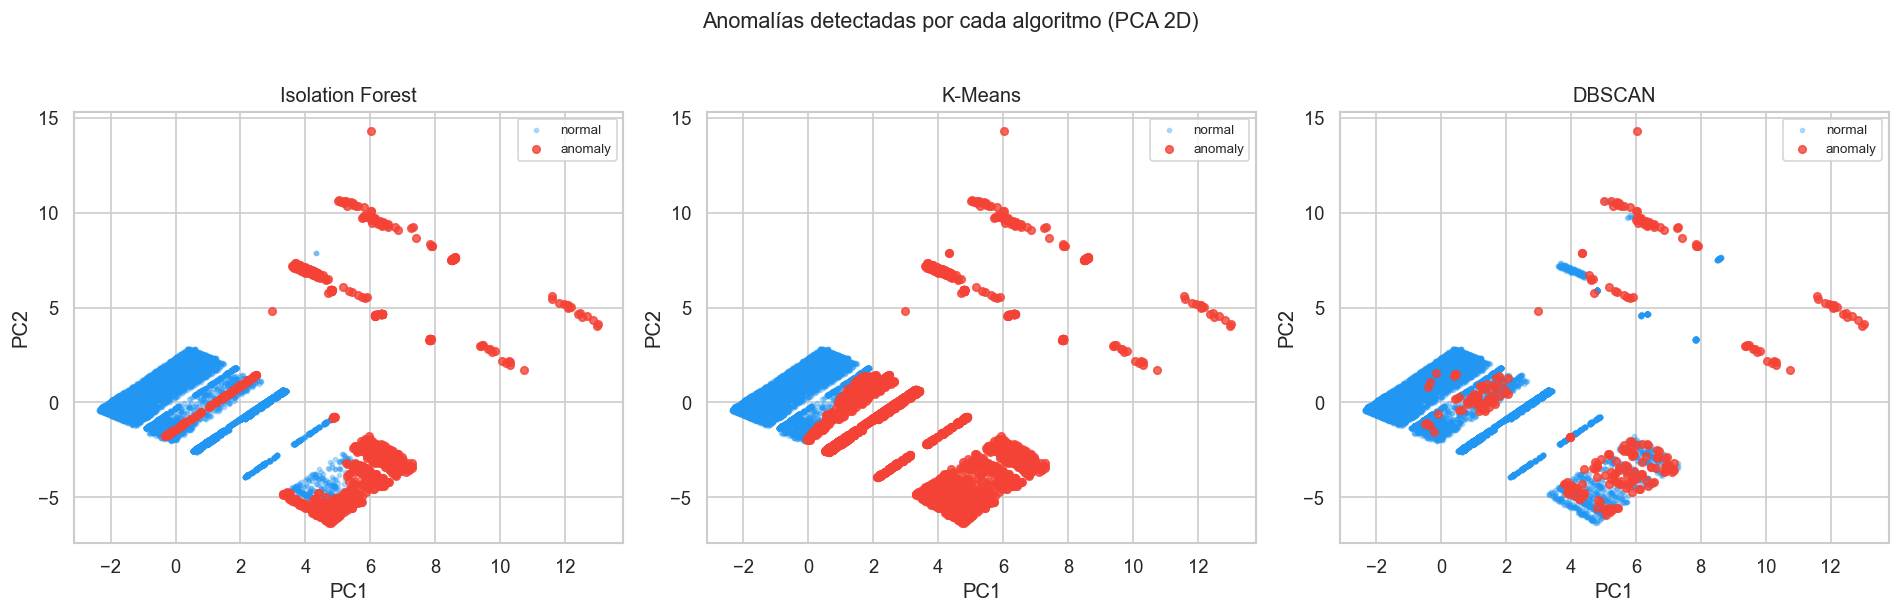

In [15]:
# Visualización comparativa de anomaly scores con PCA
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pca2 = PCA(n_components=2, random_state=42)
X_p = pca2.fit_transform(X)

configs = [
    ('Isolation Forest', if_pred),
    ('K-Means',          km_pred),
    ('DBSCAN',           db_pred),
]

for ax, (name, pred) in zip(axes, configs):
    normal_mask  = pred == 0
    anomaly_mask = pred == 1
    ax.scatter(X_p[normal_mask,  0], X_p[normal_mask,  1],
               c='#2196F3', alpha=0.3, s=6, label='normal')
    ax.scatter(X_p[anomaly_mask, 0], X_p[anomaly_mask, 1],
               c='#F44336', alpha=0.8, s=20, label='anomaly')
    ax.set_title(name)
    ax.legend(fontsize=8)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle('Anomalías detectadas por cada algoritmo (PCA 2D)', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'model_comparison_pca.png', bbox_inches='tight')
plt.show()

## Resumen de resultados

`contamination=0.05` (estimación a priori, sin usar el label real — antes se usaba 0.27, el % real de anomalías, lo cual era fuga de información hacia un modelo "no supervisado").

| Algoritmo | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|
| Isolation Forest (contamination=0.05) | 0.823 | 0.153 | 0.258 | 0.887 |
| K-Means (k=2) | 0.903 | 0.822 | **0.860** | — |
| DBSCAN (eps=0.3) | 0.611 | 0.027 | 0.051 | — |

**Conclusión:** con una estimación honesta de `contamination`, Isolation Forest prioriza precisión sobre cobertura (0.823 vs. recall 0.153): es muy confiable cuando marca algo como anómalo, pero deja pasar la mayoría de las anomalías reales porque solo espera que el 5% del tráfico lo sea. K-Means (k=2) es el mejor algoritmo en F1 en este dataset porque las anomalías generadas son numéricamente muy distintas del tráfico normal y forman un cluster compacto y separado — no depende de asumir una tasa de contaminación. DBSCAN sigue sin ser apto para anomalías volumétricas (ataques que forman sus propios clusters densos), lo cual es un hallazgo negativo con valor académico.

El análisis de sensibilidad (celda anterior) muestra que el F1 de Isolation Forest sube de forma prácticamente monótona a medida que `contamination` se acerca al 27% real — es decir, el modelo funciona mejor cuanto más "hace trampa". Reportar el número honesto (0.05) es menos favorable pero es el que se sostiene ante un jurado.